In [1]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

### Iš anksto paruošiam įvairius embedding'us

In [2]:
distance_matrix = np.load('dist_mat.npy')
original_data = np.load('original_data.npy')
labels = np.load('ship-types.npy')
_, labels_encoded = np.unique(labels, return_inverse=True)

# Projekcijų sudarymas ir įvertinimas

In [3]:
embedding = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=2,
    random_state=42
).fit_transform(distance_matrix)

embedding25 = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    max_iter=500,
    n_components=25,
    method='exact',
    random_state=42
).fit_transform(distance_matrix)

embedding100 = TSNE(
    perplexity=5,
    early_exaggeration=24,
    learning_rate=10,
    n_components=100,
    max_iter=500,
    method='exact',
    random_state=42
).fit_transform(distance_matrix)

In [4]:
from zadu.measures import class_aware_trustworthiness_continuity

In [5]:
def measure_continuity_trustworthiness(
    original_flat: np.ndarray,
    embedding: np.ndarray,
    labels: np.ndarray[str]
) -> tuple[float]:
    
    trust_scores = []
    cont_scores = []

    for k in range(5, 30):
        ca_tc = class_aware_trustworthiness_continuity.measure(
            original_flat,
            embedding,
            label=labels,
            k=k
        )

        trust_scores.append(ca_tc["ca_trustworthiness"])
        cont_scores.append(ca_tc["ca_continuity"])

    trust_score = float(np.mean(trust_scores))
    cont_score = float(np.mean(cont_scores))

    return cont_score, trust_score

In [6]:
original_flat = original_data.reshape((-1, 250))
cont2, trust2 = measure_continuity_trustworthiness(
    original_flat, embedding, labels
)

cont25, trust25 = measure_continuity_trustworthiness(
    original_flat, embedding25, labels
)

cont100, trust100 = measure_continuity_trustworthiness(
    original_flat, embedding100, labels
)

In [7]:
import pandas as pd

data = {
    "Dimensija": [2, 25, 100],
    "Tęstinumas": [cont2, cont25, cont100],
    "Patikimumas": [trust2, trust25, trust100],
}

print(pd.DataFrame(data)\
    .to_latex()\
    .replace('.', ','))

\begin{tabular}{lrrr}
\toprule
 & Dimensija & Tęstinumas & Patikimumas \\
\midrule
0 & 2 & 0,987661 & 0,980828 \\
1 & 25 & 0,982749 & 0,966229 \\
2 & 100 & 0,978805 & 0,959402 \\
\bottomrule
\end{tabular}



> Kadangi tiek tęstinumo, tiek patikimumo viršija 0,95, tai yra labai gera projekcija lokalios struktūros atžvilgiu -> mes naudosime šitą dimensijos mažinimą toliau

# Hierarchinis klasterizavimas

In [8]:
n = original_data.shape[0]
np.sqrt(n / 2)

np.float64(19.364916731037084)

#### Maksimum 20 klasterių tikrinsime 

In [9]:
all_metrics = {
    'Metrika': [],
    'Hiperparametrų rinkinys': [],
    'Dimensija': [],
    'Metodas': [],
    'Metrikos reikšmė': []
}

In [10]:
def calculate_wcbcr(clusters, distance_matrix):
    """ Calculate Within-Cluster to Between-Cluster Ratio (WCBCR). """

    clusters = np.array(clusters)
    distance_matrix = np.array(distance_matrix)
    unique_clusters = np.unique(clusters)

    # Group point indices by cluster label
    # Key - cluster number, value - list of indices that belong to that cluster number 
    cluster_members = {k: np.where(clusters == k)[0] for k in unique_clusters}

    # Compute medoid for each cluster
    centroids = {}
    for k, members in cluster_members.items():
        if len(members) == 1:
            centroids[k] = members[0]
        else:
            intra_distances = [sum(distance_matrix[p][q] for q in members) for p in members]
            centroids[k] = members[np.argmin(intra_distances)]

    # Numerator: sum of distances from each point to its cluster medoid
    numerator = sum(
        distance_matrix[point][centroids[k]]
        for k, members in cluster_members.items()
        for point in members
    )

    # Denominator: sum of distances between all distinct centroid pairs (i ≠ j)
    centroid_list = list(centroids.values())
    K = len(centroid_list)
    denominator = sum(
        distance_matrix[centroid_list[i]][centroid_list[j]]
        for i in range(K)
        for j in range(K)
        if i != j
    )

    if denominator == 0:
        raise ValueError("Denominator is zero: all centroids are identical.")

    return numerator / denominator

def inertia_score(embeddings, clusters):
    clusters = np.array(clusters)
    unique_clusters = np.unique(clusters)
    inertia = 0.0

    for cluster_id in unique_clusters:
        # Get all points belonging to this cluster
        mask = clusters == cluster_id
        cluster_points = embeddings[mask]
        
        # Calculate centroid
        centroid = cluster_points.mean(axis=0)
        
        # Sum of squared euclidean distances from each point to its centroid
        diff = cluster_points - centroid
        inertia += np.sum(diff ** 2)
    
    return inertia

In [11]:
def evaluate_clustering_dist_mat(dist_mat, data_flat, max_n, labels, linkage):
    """
    Grazina: 
        Siluetu,
        WCBRC,
        ARI,
        NMI,
        Calinski-Harabasz,
        Davies-Bouldvin
    """

    silhouette_scores = []
    inertia_scores = []
    ari_scores = []
    nmi_scores = []
    ch_scores = []
    db_scores = []

    for n in range(2, max_n):
        clusters = AgglomerativeClustering(n_clusters=n, metric='precomputed', linkage=linkage)\
            .fit_predict(dist_mat)

        score = silhouette_score(dist_mat, clusters, metric='precomputed')
        silhouette_scores.append(score)

        # Elbow method: compute inertia (mean intra-cluster distance)
        wcbcr = calculate_wcbcr(clusters, dist_mat)
        inertia_scores.append(wcbcr)

        ari_scores.append( adjusted_rand_score(labels, clusters) )
        nmi_scores.append( normalized_mutual_info_score(labels, clusters) )

        ch_scores.append( calinski_harabasz_score(data_flat, clusters) )
        db_scores.append( davies_bouldin_score(data_flat, clusters) )

    return silhouette_scores, inertia_scores, ari_scores, nmi_scores, ch_scores, db_scores

def evaluate_clustering_embeddings(embedding, max_n, labels, linkage):
    """
    Grazina: 
        Siluetu,
        WCBRC,
        ARI,
        NMI,
        Calinski-Harabasz,
        Davies-Bouldvin
    """

    silhouette_scores = []
    inertia_scores = []
    ari_scores = []
    nmi_scores = []
    ch_scores = []
    db_scores = []

    for n in range(2, max_n):
        clusters = AgglomerativeClustering(n_clusters=n, metric='euclidean', linkage=linkage)\
            .fit_predict(embedding)

        score = silhouette_score(embedding, clusters, metric='euclidean')
        silhouette_scores.append(score)

        # Elbow method: compute inertia (mean intra-cluster distance)
        inertia = inertia_score(embedding, clusters)
        inertia_scores.append(inertia)

        ari_scores.append( adjusted_rand_score(labels, clusters) )
        nmi_scores.append( normalized_mutual_info_score(labels, clusters) )

        ch_scores.append( calinski_harabasz_score(embedding, clusters) )
        db_scores.append( davies_bouldin_score(embedding, clusters) )

    return silhouette_scores, inertia_scores, ari_scores, nmi_scores, ch_scores, db_scores

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform

In [13]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

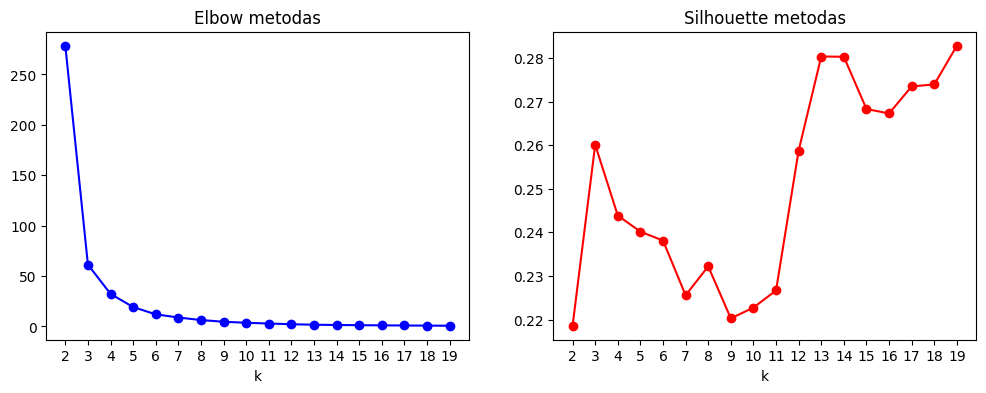

In [14]:
silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_dist_mat(
    distance_matrix,
    original_flat,
    20,
    labels,
    linkage='complete'
)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 20), wcbrc, 'bo-')
plt.title('Elbow metodas'); plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.subplot(1, 2, 2)
plt.plot(range(2, 20), silhouette_scores, 'ro-')
plt.title('Silhouette metodas')
plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.show()

In [15]:
NUMBER_OF_METRICS = 6

for linkage in ['complete', 'average', 'single']:
    silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_dist_mat(
        distance_matrix,
        original_flat,
        20,
        labels,
        linkage=linkage
    )

    all_metrics['Dimensija'].extend( ['originali'] * len(silhouette_scores) )
    all_metrics['Metrika'].extend( ['Silhouete'] * len(silhouette_scores) )
    all_metrics['Metrikos reikšmė'].extend( silhouette_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(silhouette_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(silhouette_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(ari_scores) )
    all_metrics['Metrika'].extend( ['ARI'] * len(ari_scores) )
    all_metrics['Metrikos reikšmė'].extend( ari_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ari_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ari_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(nmi_scores) )
    all_metrics['Metrika'].extend( ['NMI'] * len(nmi_scores) )
    all_metrics['Metrikos reikšmė'].extend( nmi_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(nmi_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(nmi_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(ch_scores) )
    all_metrics['Metrika'].extend( ['Calinski-Harabasz'] * len(ch_scores) )
    all_metrics['Metrikos reikšmė'].extend( ch_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ch_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ch_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(db_scores) )
    all_metrics['Metrika'].extend( ['Davies-Bouldin'] * len(db_scores) )
    all_metrics['Metrikos reikšmė'].extend( db_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(db_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(db_scores))

### Pagal siluetus: 20, pagal elbow - 5

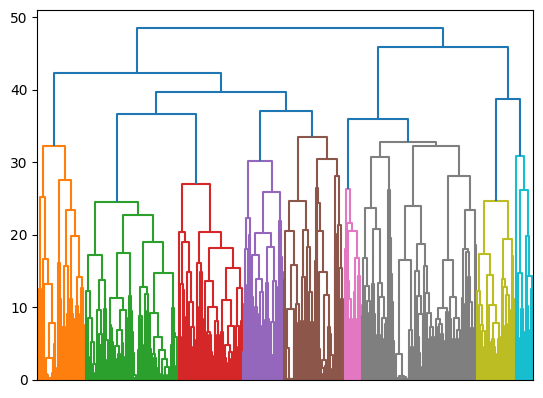

In [16]:
model = AgglomerativeClustering(
    20, metric='precomputed',
    linkage='complete',
    compute_distances=True 
)

clusters20 = model.fit_predict(distance_matrix)

plot_dendrogram(model, truncate_mode="level")
plt.xticks(ticks=[], labels=[])
plt.show()

<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

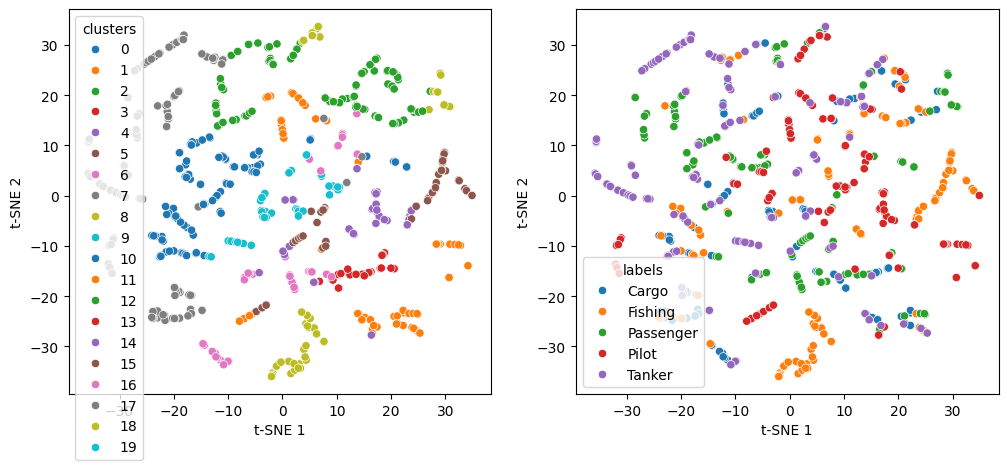

In [17]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters20

n_clusters = len(np.unique(clusters20))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[0],
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['labels'] = labels

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[1],
    hue='labels',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

### Dimensija 2

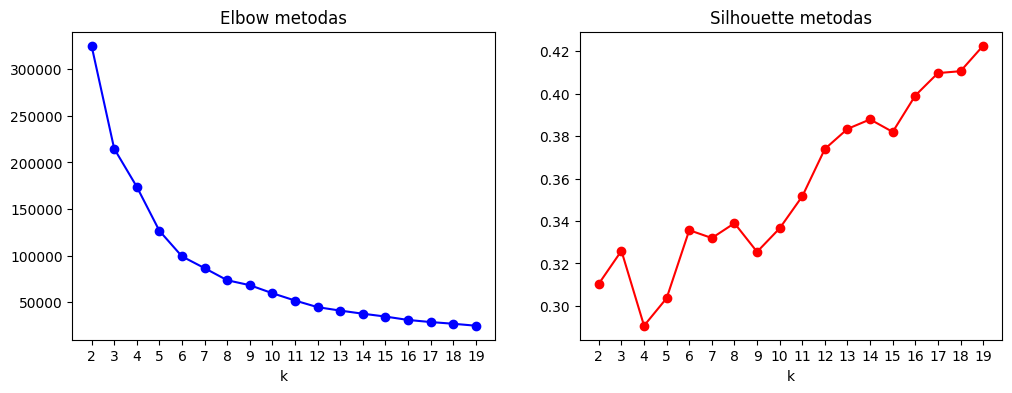

In [18]:
silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(embedding, max_n=20, labels=labels, linkage='complete')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 20), wcbrc, 'bo-')
plt.title('Elbow metodas'); plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.subplot(1, 2, 2)
plt.plot(range(2, 20), silhouette_scores, 'ro-')
plt.title('Silhouette metodas')
plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.show()

In [19]:
NUMBER_OF_METRICS = 6

for linkage in ['complete', 'average', 'single']:
    silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(
        embedding,
        20,
        labels,
        linkage=linkage
    )

    all_metrics['Dimensija'].extend( ['2'] * len(silhouette_scores) )
    all_metrics['Metrika'].extend( ['Silhouete'] * len(silhouette_scores) )
    all_metrics['Metrikos reikšmė'].extend( silhouette_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(silhouette_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(silhouette_scores))

    all_metrics['Dimensija'].extend( ['2'] * len(ari_scores) )
    all_metrics['Metrika'].extend( ['ARI'] * len(ari_scores) )
    all_metrics['Metrikos reikšmė'].extend( ari_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ari_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ari_scores))

    all_metrics['Dimensija'].extend( ['2'] * len(nmi_scores) )
    all_metrics['Metrika'].extend( ['NMI'] * len(nmi_scores) )
    all_metrics['Metrikos reikšmė'].extend( nmi_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(nmi_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(nmi_scores))

    all_metrics['Dimensija'].extend( ['2'] * len(ch_scores) )
    all_metrics['Metrika'].extend( ['Calinski-Harabasz'] * len(ch_scores) )
    all_metrics['Metrikos reikšmė'].extend( ch_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ch_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ch_scores))

    all_metrics['Dimensija'].extend( ['2'] * len(db_scores) )
    all_metrics['Metrika'].extend( ['Davies-Bouldin'] * len(db_scores) )
    all_metrics['Metrikos reikšmė'].extend( db_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(db_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(db_scores))

### Pagal elbow metodą - 10, pagal siluetus - 20

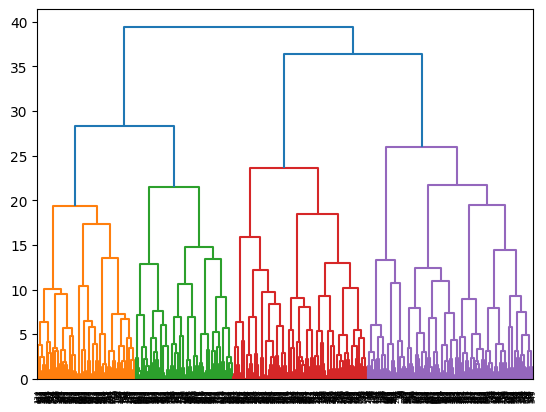

In [20]:
model = AgglomerativeClustering(
    5, metric='euclidean',
    linkage='average',
    compute_distances=True 
)

clusters = model.fit_predict(embedding)

plot_dendrogram(model, truncate_mode="level")

In [22]:
silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(embedding, max_n=20, labels=labels, linkage='complete')

In [45]:
clusters5 = AgglomerativeClustering(
    10, metric='euclidean',
    linkage='complete',
    compute_distances=True 
).fit_predict(embedding)

clusters20 = AgglomerativeClustering(
    20, metric='euclidean',
    linkage='complete',
    compute_distances=True 
).fit_predict(embedding)

<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

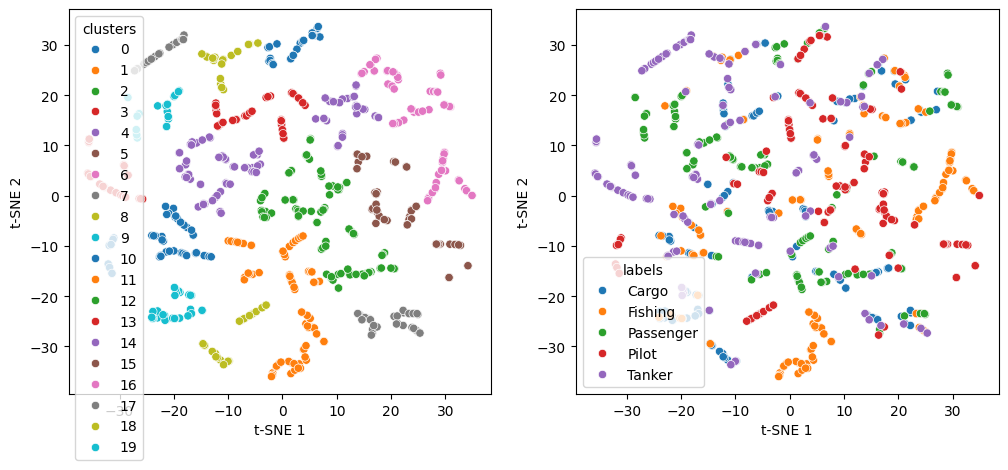

In [46]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters20

n_clusters = len(np.unique(clusters20))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[0],
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['labels'] = labels

n_clusters = len(np.unique(clusters5))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[1],
    hue='labels',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5)
)

### Dimensija 25

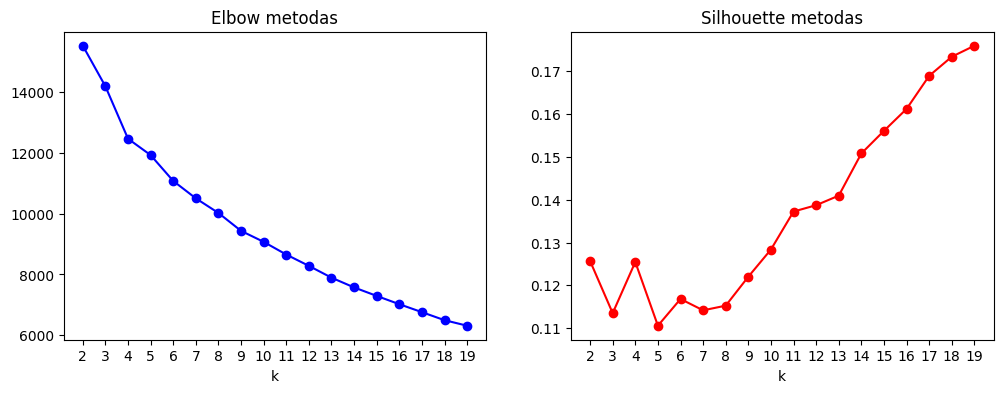

In [26]:
silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(embedding25, labels=labels, max_n=20, linkage='complete')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 20), wcbrc, 'bo-')
plt.title('Elbow metodas'); plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.subplot(1, 2, 2)
plt.plot(range(2, 20), silhouette_scores, 'ro-')
plt.title('Silhouette metodas')
plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.show()

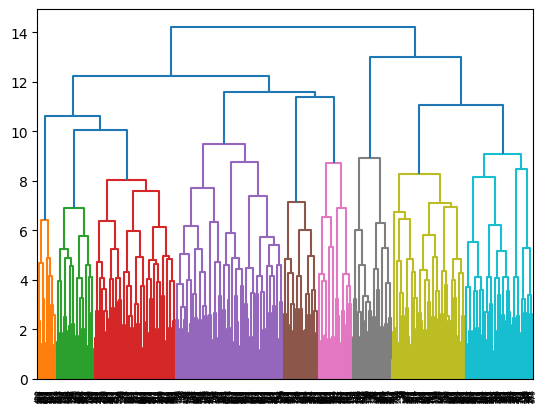

In [28]:
model = AgglomerativeClustering(
    5, metric='euclidean',
    linkage='complete',
    compute_distances=True 
)

clusters = model.fit_predict(embedding25)

plot_dendrogram(model, truncate_mode="level")

In [31]:
NUMBER_OF_METRICS = 6

for linkage in ['complete', 'average', 'single']:
    silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(
        embedding25,
        20,
        labels,
        linkage=linkage
    )

    all_metrics['Dimensija'].extend( ['25'] * len(silhouette_scores) )
    all_metrics['Metrika'].extend( ['Silhouete'] * len(silhouette_scores) )
    all_metrics['Metrikos reikšmė'].extend( silhouette_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(silhouette_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(silhouette_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(ari_scores) )
    all_metrics['Metrika'].extend( ['ARI'] * len(ari_scores) )
    all_metrics['Metrikos reikšmė'].extend( ari_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ari_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ari_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(nmi_scores) )
    all_metrics['Metrika'].extend( ['NMI'] * len(nmi_scores) )
    all_metrics['Metrikos reikšmė'].extend( nmi_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(nmi_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(nmi_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(ch_scores) )
    all_metrics['Metrika'].extend( ['Calinski-Harabasz'] * len(ch_scores) )
    all_metrics['Metrikos reikšmė'].extend( ch_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ch_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ch_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(db_scores) )
    all_metrics['Metrika'].extend( ['Davies-Bouldin'] * len(db_scores) )
    all_metrics['Metrikos reikšmė'].extend( db_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(db_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(db_scores))

In [50]:
clusters20 = AgglomerativeClustering(
    20, metric='euclidean',
    linkage='complete',
    compute_distances=True 
).fit_predict(embedding25)

<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

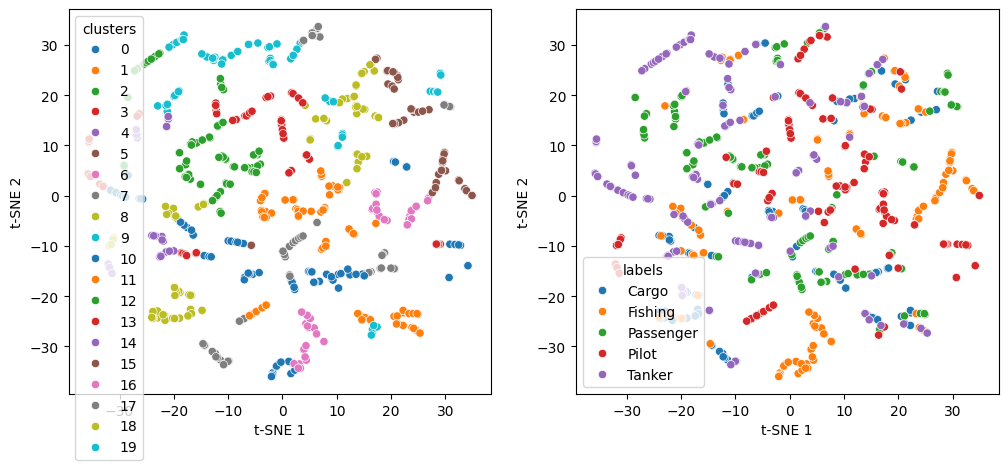

In [51]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters20

n_clusters = len(np.unique(clusters20))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5),
    ax=axs[0]
)

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['labels'] = labels

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[1],
    hue='labels',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5),
)

### Dimensija 100

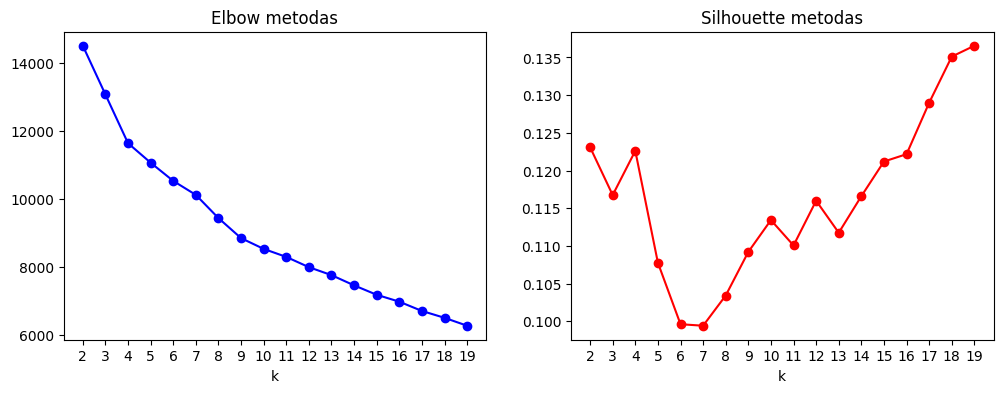

In [39]:
silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(embedding100, max_n=20, labels=labels, linkage='complete')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(2, 20), wcbrc, 'bo-')
plt.title('Elbow metodas'); plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.subplot(1, 2, 2)
plt.plot(range(2, 20), silhouette_scores, 'ro-')
plt.title('Silhouette metodas')
plt.xlabel('k')
plt.xticks(ticks=range(2,20), labels=[str(x) for x in range(2, 20)])

plt.show()

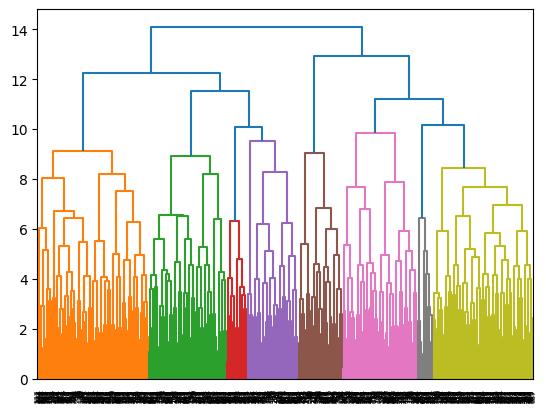

In [40]:
model = AgglomerativeClustering(
    5, metric='euclidean',
    linkage='complete',
    compute_distances=True 
)

clusters = model.fit_predict(embedding100)

plot_dendrogram(model, truncate_mode="level")

In [ ]:
NUMBER_OF_METRICS = 6

for linkage in ['complete', 'average', 'single']:
    silhouette_scores, wcbrc, ari_scores, nmi_scores, ch_scores, db_scores = evaluate_clustering_embeddings(
        embedding100,
        20,
        labels,
        linkage=linkage
    )

    all_metrics['Dimensija'].extend( ['100'] * len(silhouette_scores) )
    all_metrics['Metrika'].extend( ['Silhouete'] * len(silhouette_scores) )
    all_metrics['Metrikos reikšmė'].extend( silhouette_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(silhouette_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(silhouette_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(ari_scores) )
    all_metrics['Metrika'].extend( ['ARI'] * len(ari_scores) )
    all_metrics['Metrikos reikšmė'].extend( ari_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ari_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ari_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(nmi_scores) )
    all_metrics['Metrika'].extend( ['NMI'] * len(nmi_scores) )
    all_metrics['Metrikos reikšmė'].extend( nmi_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(nmi_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(nmi_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(ch_scores) )
    all_metrics['Metrika'].extend( ['Calinski-Harabasz'] * len(ch_scores) )
    all_metrics['Metrikos reikšmė'].extend( ch_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(ch_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(ch_scores))

    all_metrics['Dimensija'].extend( ['originali'] * len(db_scores) )
    all_metrics['Metrika'].extend( ['Davies-Bouldin'] * len(db_scores) )
    all_metrics['Metrikos reikšmė'].extend( db_scores )
    all_metrics['Metodas'].extend( ['Hierarchinis'] * len(db_scores) )
    all_metrics['Hiperparametrų rinkinys'].extend( [{'Jungimo matas': linkage}] * len(db_scores))

In [52]:
clusters20 = AgglomerativeClustering(
    20, metric='euclidean',
    linkage='average',
    compute_distances=True 
).fit_predict(embedding100)

<Axes: xlabel='t-SNE 1', ylabel='t-SNE 2'>

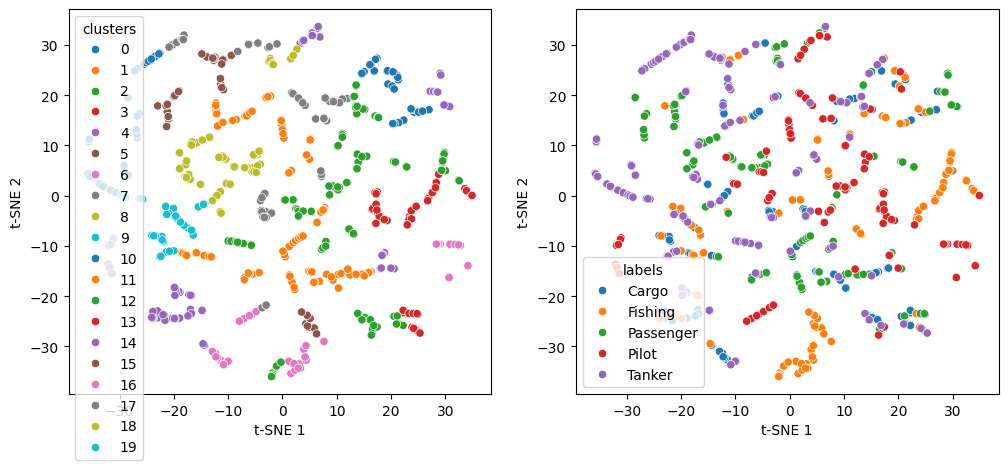

In [53]:
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['clusters'] = clusters20

n_clusters = len(np.unique(clusters20))

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    hue='clusters',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5),
    ax=axs[0]
)

df_res = pd.DataFrame(embedding, columns=['t-SNE 1', 't-SNE 2'])
df_res['labels'] = labels

sns.scatterplot(
    data=df_res, x='t-SNE 1', y='t-SNE 2',
    ax=axs[1],
    hue='labels',
    palette='tab10',
    hue_norm=(-0.5, n_clusters - 0.5),
)

In [54]:
result_df = pd.DataFrame(all_metrics)

In [69]:
for metrika, metric_results in result_df.groupby('Metrika'):
    if metrika not in ['ARI', 'NMI']:
        continue

    index_best_metric = metric_results['Metrikos reikšmė'].argmax()
    best_hyper = metric_results.iloc[index_best_metric, :]

    print( f'Metrikai {metrika} geriausia dimensija:\n', best_hyper['Dimensija'] )
    print( f'Metrikai {metrika} geriausias jungties matas:\n', best_hyper['Hiperparametrų rinkinys'] )
    print('\n')

Metrikai ARI geriausia dimensija:
 2
Metrikai ARI geriausias jungties matas:
 {'Jungimo matas': 'complete'}


Metrikai NMI geriausia dimensija:
 2
Metrikai NMI geriausias jungties matas:
 {'Jungimo matas': 'single'}




# Kmeans


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, 
                             davies_bouldin_score, adjusted_rand_score, 
                             normalized_mutual_info_score, jaccard_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [ ]:
def find_elbow_k(k_range, sse):
    """Automatiškai randa alkūnės tašką (didžiausią kreivės lūžį)"""
    # Naudojame vektorių atstumą nuo tiesės tarp pirmo ir paskutinio taško
    p1 = np.array([k_range[0], sse[0]])
    p2 = np.array([k_range[-1], sse[-1]])
    distances = []
    for i in range(len(k_range)):
        p0 = np.array([k_range[i], sse[i]])
        # Atstumo formulė nuo taško iki tiesės
        dist = np.abs(np.cross(p2-p1, p1-p0)) / np.linalg.norm(p2-p1)
        distances.append(dist)
    return k_range[np.argmax(distances)]

# --- VIZUALIZACIJOS STILIUS ---
def draw_styled_clusters(ax, data, labels, title):
    unique_labels = np.unique(labels)
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    ax.set_title(title, fontsize=12, fontweight='bold')
    
    for i, label in enumerate(unique_labels):
        points = data[labels == label]
        color = colors[i]
        ax.scatter(points[:, 0], points[:, 1], color=color, s=15, alpha=0.5)
        
        if len(data) < 300:
            indices = np.where(labels == label)[0]
            for idx, pt in zip(indices, points):
                ax.text(pt[0], pt[1], str(idx), fontsize=7, color=color)

        if len(points) > 2:
            mean = np.mean(points, axis=0)
            cov = np.cov(points, rowvar=False)
            vals, vecs = np.linalg.eigh(cov)
            order = vals.argsort()[::-1]
            vals, vecs = vals[order], vecs[:, order]
            theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
            width, height = 2 * 2 * np.sqrt(np.abs(vals))
            
            ell = patches.Ellipse(xy=mean, width=width, height=height, angle=theta,
                                  edgecolor=color, facecolor='none', linewidth=1.5,
                                  hatch='////', alpha=0.2)
            ax.add_patch(ell)
            ax.text(mean[0], mean[1], f"K{label}", fontsize=12, fontweight='bold', color='black')

            
def perform_full_analysis(data, labels_true, dim_name):
    print(f"\n{'-'*15} ANALIZĖ: {dim_name} {'-'*15}")
    k_range = range(2, 16)
    sse = []
    sil_scores = []
    results_by_k = {}

    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        l_pred = km.fit_predict(data)
        
        sse_val = km.inertia_
        sil_val = silhouette_score(data, l_pred)
        sse.append(sse_val)
        sil_scores.append(sil_val)
        
        results_by_k[k] = {
            'sil': sil_val,
            'ch': calinski_harabasz_score(data, l_pred),
            'db': davies_bouldin_score(data, l_pred),
            'ari': adjusted_rand_score(labels_true, l_pred),
            'nmi': normalized_mutual_info_score(labels_true, l_pred),
            'jac': jaccard_score(labels_true, l_pred, average='macro')
        }

    k_silhouette = k_range[np.argmax(sil_scores)]
    k_elbow = find_elbow_k(list(k_range), sse)

    # --- VIZUALIZACIJA (1x4) ---
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(25, 5))
    ax1.plot(k_range, sse, 'bo-'); ax1.set_title("Elbow"); ax1.axvline(k_elbow, color='orange', ls='--')
    ax2.plot(k_range, sil_scores, 'ro-'); ax2.set_title("Silhouette"); ax2.axvline(k_silhouette, color='green', ls='--')
    
    viz_2d = data if data.shape[1] == 2 else TSNE(n_components=2, random_state=42).fit_transform(data)
    
    # Optimalus K projekcija
    final_labels_opt = KMeans(n_clusters=k_silhouette, random_state=42, n_init=10).fit_predict(data)
    draw_styled_clusters(ax3, viz_2d, final_labels_opt, f"Optimalus K={k_silhouette}")
    
    # Fiksuotas K=5 projekcija
    fixed_k = 5
    final_labels_5 = KMeans(n_clusters=fixed_k, random_state=42, n_init=10).fit_predict(data)
    draw_styled_clusters(ax4, viz_2d, final_labels_5, f"Fiksuotas K={fixed_k}")
    
    plt.tight_layout()
    plt.show()

    # --- REZULTATŲ PARUOŠIMAS ---
    # 1. Rezultatai su optimaliu K
    res_opt = results_by_k[k_silhouette]
    opt_entry = {
        'Dimensija': f"{dim_name} (Opt)", 'K': k_silhouette, 'Metodas': 'Silhouette',
        'Silhouette': res_opt['sil'], 'CH': res_opt['ch'], 'DB': res_opt['db'], 
        'ARI': res_opt['ari'], 'NMI': res_opt['nmi'], 'Jaccard': res_opt['jac']
    }
    
    # 2. Rezultatai su fiksuotu K=5
    res_5 = results_by_k[fixed_k]
    fixed_entry = {
        'Dimensija': f"{dim_name} (K=5)", 'K': fixed_k, 'Metodas': 'Fiksuotas',
        'Silhouette': res_5['sil'], 'CH': res_5['ch'], 'DB': res_5['db'], 
        'ARI': res_5['ari'], 'NMI': res_5['nmi'], 'Jaccard': res_5['jac']
    }

    return [opt_entry, fixed_entry] # Grąžiname sąrašą su abiem įrašais

In [ ]:
# --- 3. PAGRINDINĖ ANALIZĖ ---
dist_mat = np.load('dist_mat.npy')
original_data = np.load('original_data.npy')
labels_true_str = np.load('ship-types.npy')
le = LabelEncoder()
labels_true = le.fit_transform(labels_true_str)

# Empyrinis K
n_samples = dist_mat.shape[0]
empiric_k = int(np.sqrt(n_samples / 2))

# Paleidimas
final_summary = []

num_classes = len(np.unique(labels_true_str))

print(f"Originalių klasių (laivų tipų) skaičius: {num_classes}")

Originalių klasių (laivų tipų) skaičius: 5



--------------- ANALIZĖ: Originali ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_79451/3729950055.py:10: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2-p1, p1-p0)) / np.linalg.norm(p2-p1)


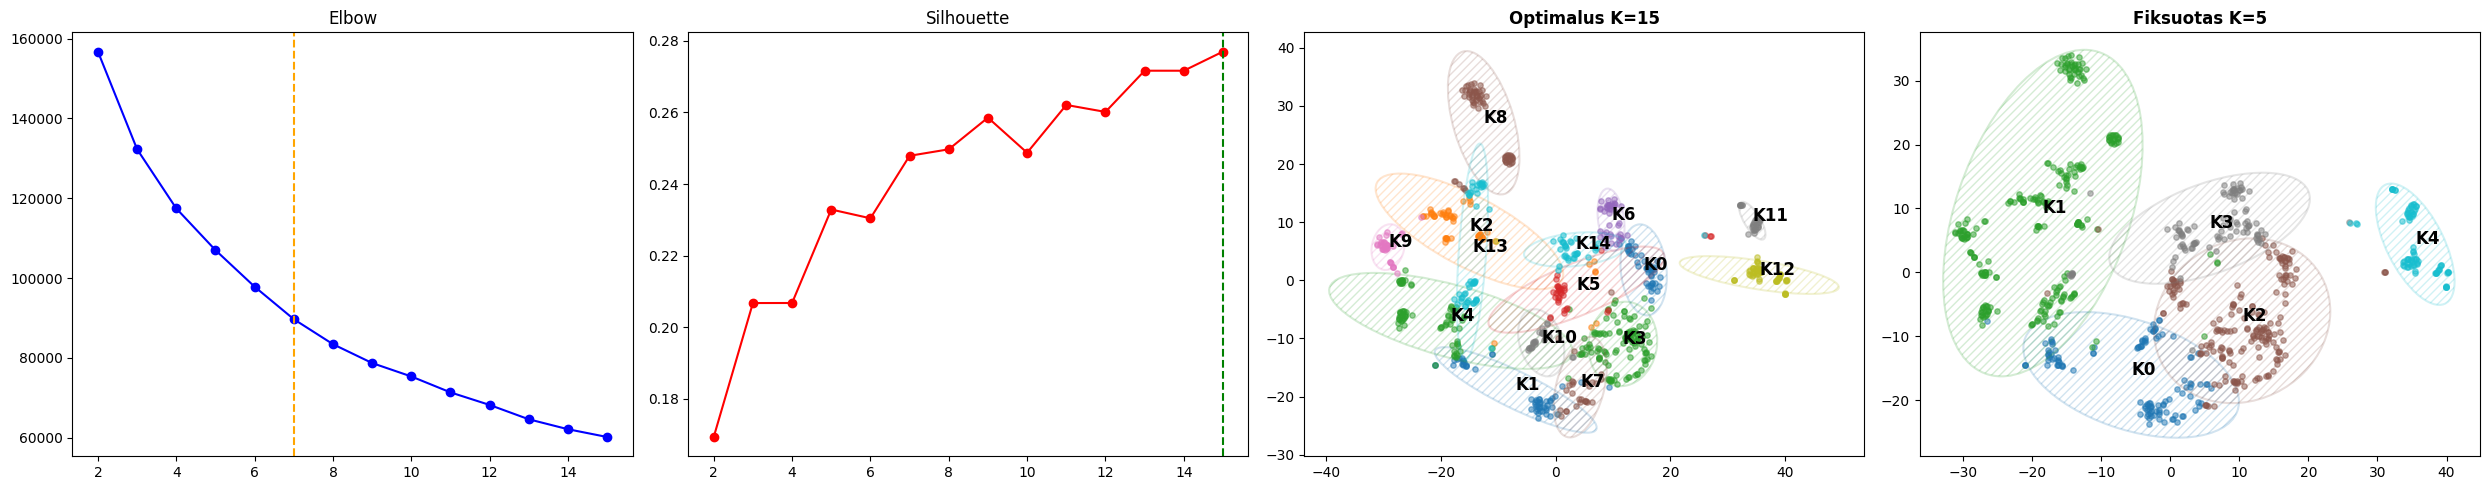

In [ ]:
original_data_scaled = StandardScaler().fit_transform(original_data.reshape(n_samples, -1))

final_summary.append(perform_full_analysis(original_data_scaled, labels_true, "Originali"))


In [ ]:

# --- 4. GALUTINIS PALYGINIMAS ---
df_final = pd.DataFrame(final_summary)
print("\n" + "="*100)
print("VISŲ DIMENSIJŲ IR OPTIMALIŲ K PALYGINIMAS")
print("="*100)
print(df_final.to_string(index=False))


VISŲ DIMENSIJŲ IR OPTIMALIŲ K PALYGINIMAS
                                                                                                                                                                                                                                                 0                                                                                                                                                                                                                                              1
{'Dimensija': 'Originali (Opt)', 'K': 15, 'Metodas': 'Silhouette', 'Silhouette': 0.27701261086615947, 'CH': 111.02641866599505, 'DB': 1.3094327215297332, 'ARI': 0.09418530068717032, 'NMI': 0.22992042842173321, 'Jaccard': 0.029884156263451568} {'Dimensija': 'Originali (K=5)', 'K': 5, 'Metodas': 'Fiksuotas', 'Silhouette': 0.23287355530965972, 'CH': 140.12637417533077, 'DB': 1.5211351672372515, 'ARI': 0.12054155366823849, 'NMI': 0.1610593720185553, 'Jaccard': 0.172702513503


--------------- ANALIZĖ: 2D ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_79451/3729950055.py:10: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2-p1, p1-p0)) / np.linalg.norm(p2-p1)


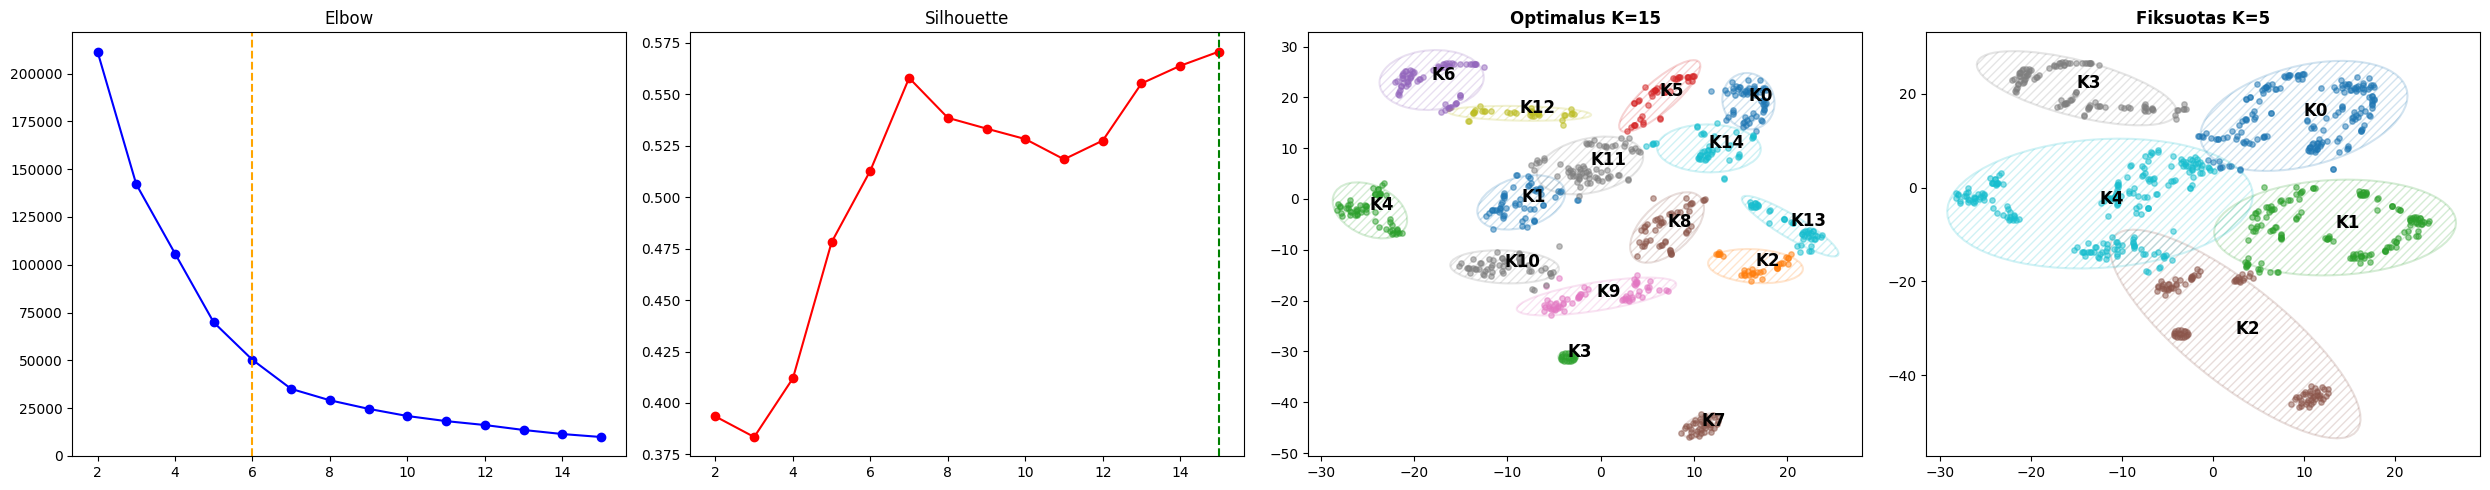


--------------- ANALIZĖ: 25D ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_79451/3729950055.py:10: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2-p1, p1-p0)) / np.linalg.norm(p2-p1)


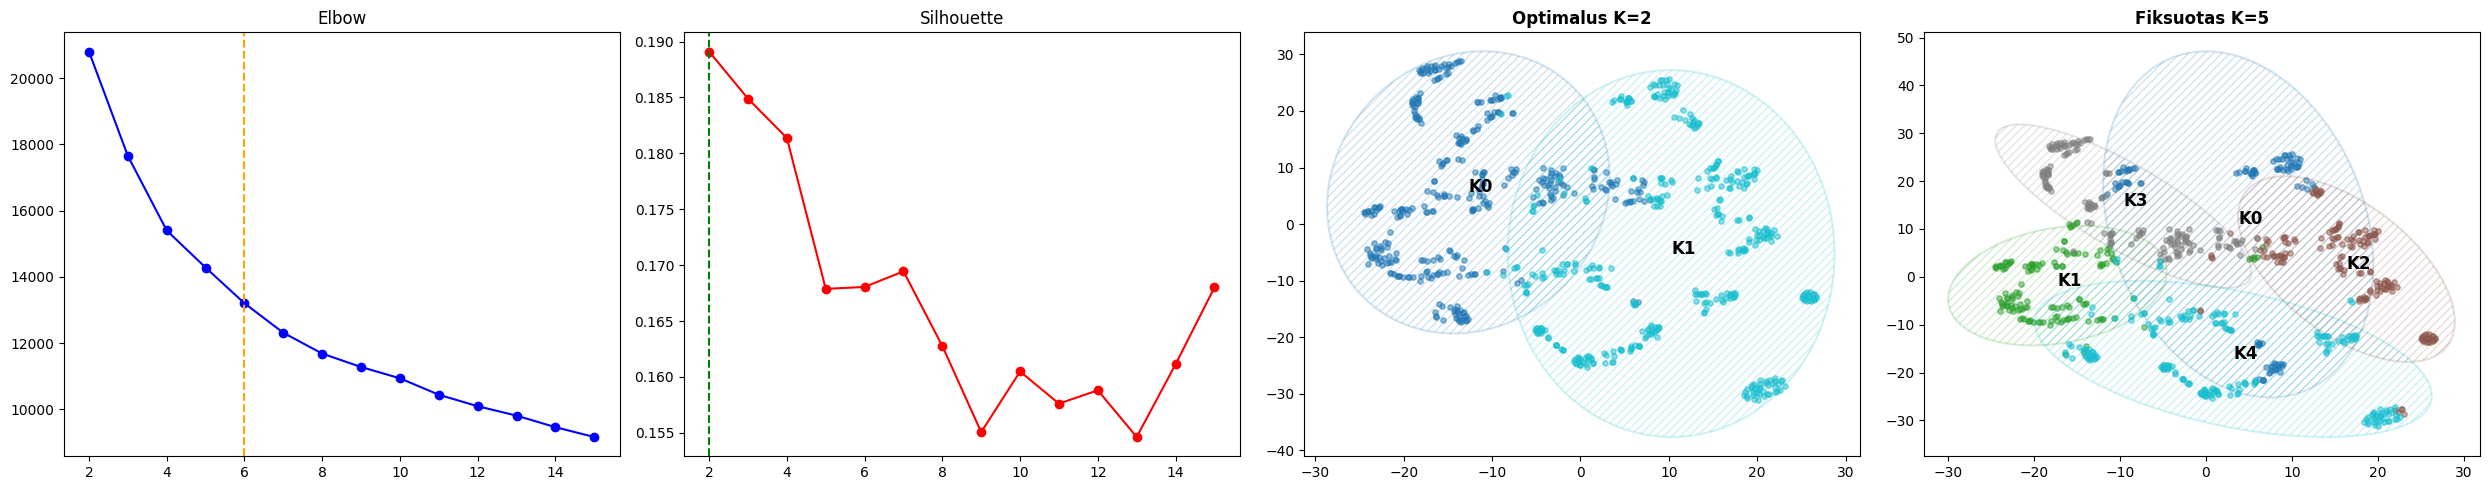


--------------- ANALIZĖ: 50D ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_79451/3729950055.py:10: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2-p1, p1-p0)) / np.linalg.norm(p2-p1)


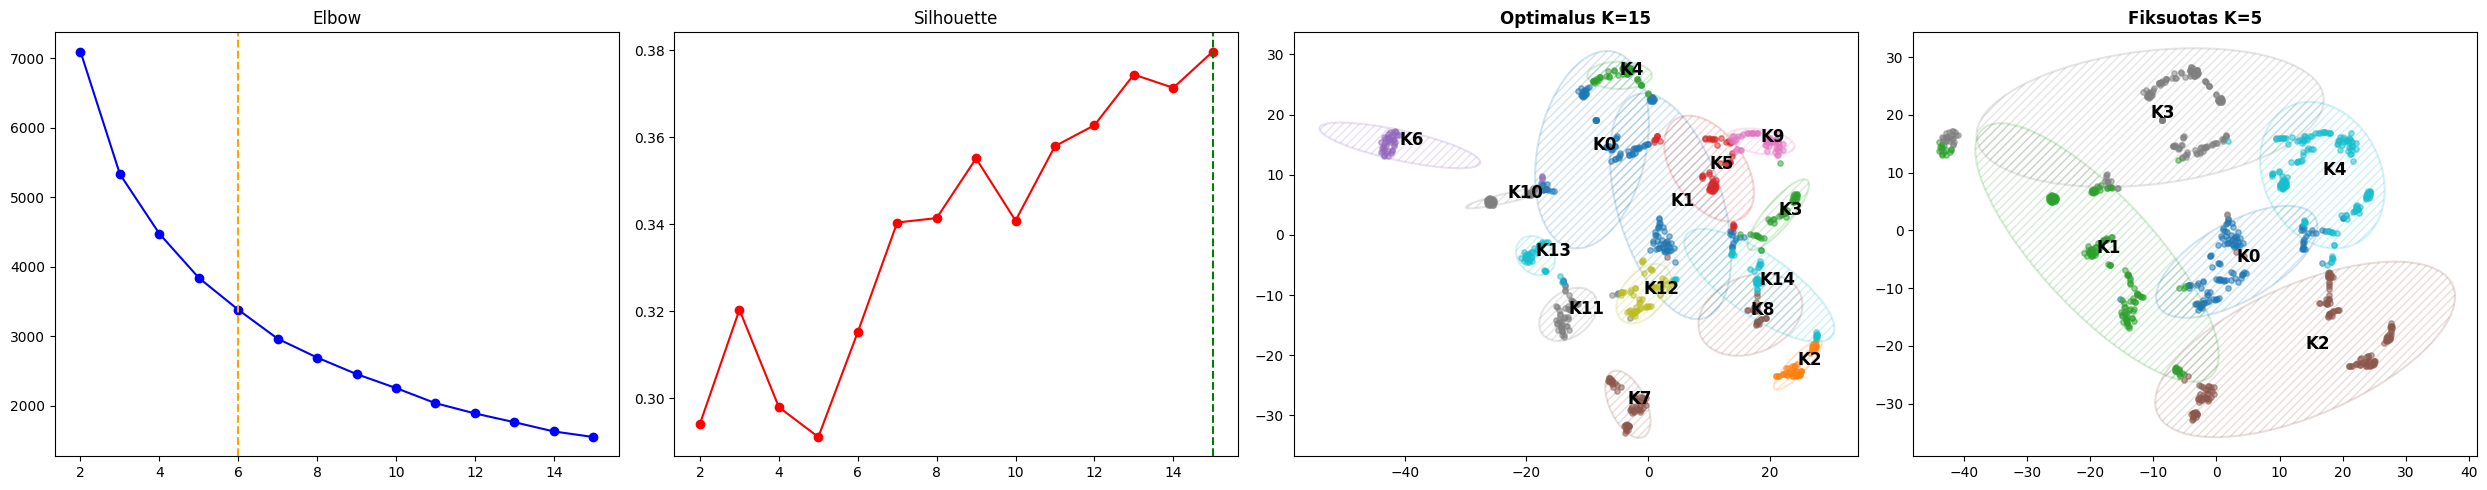


--------------- ANALIZĖ: 100D ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_79451/3729950055.py:10: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2-p1, p1-p0)) / np.linalg.norm(p2-p1)


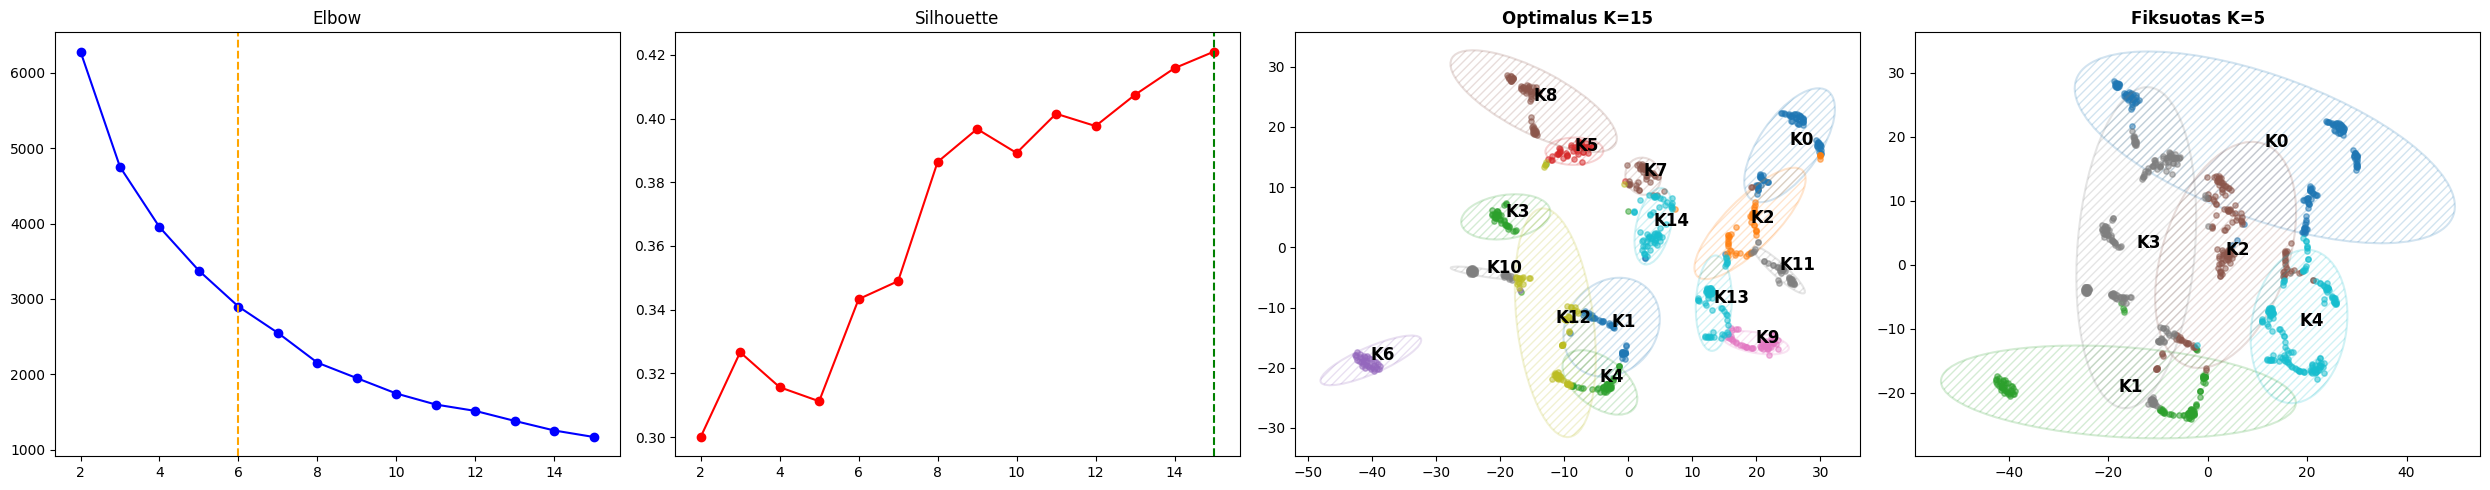


--------------- ANALIZĖ: 150D ---------------


/var/folders/_b/z2p0szkj64q2h160m5lnc8qw0000gn/T/ipykernel_79451/3729950055.py:10: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  dist = np.abs(np.cross(p2-p1, p1-p0)) / np.linalg.norm(p2-p1)


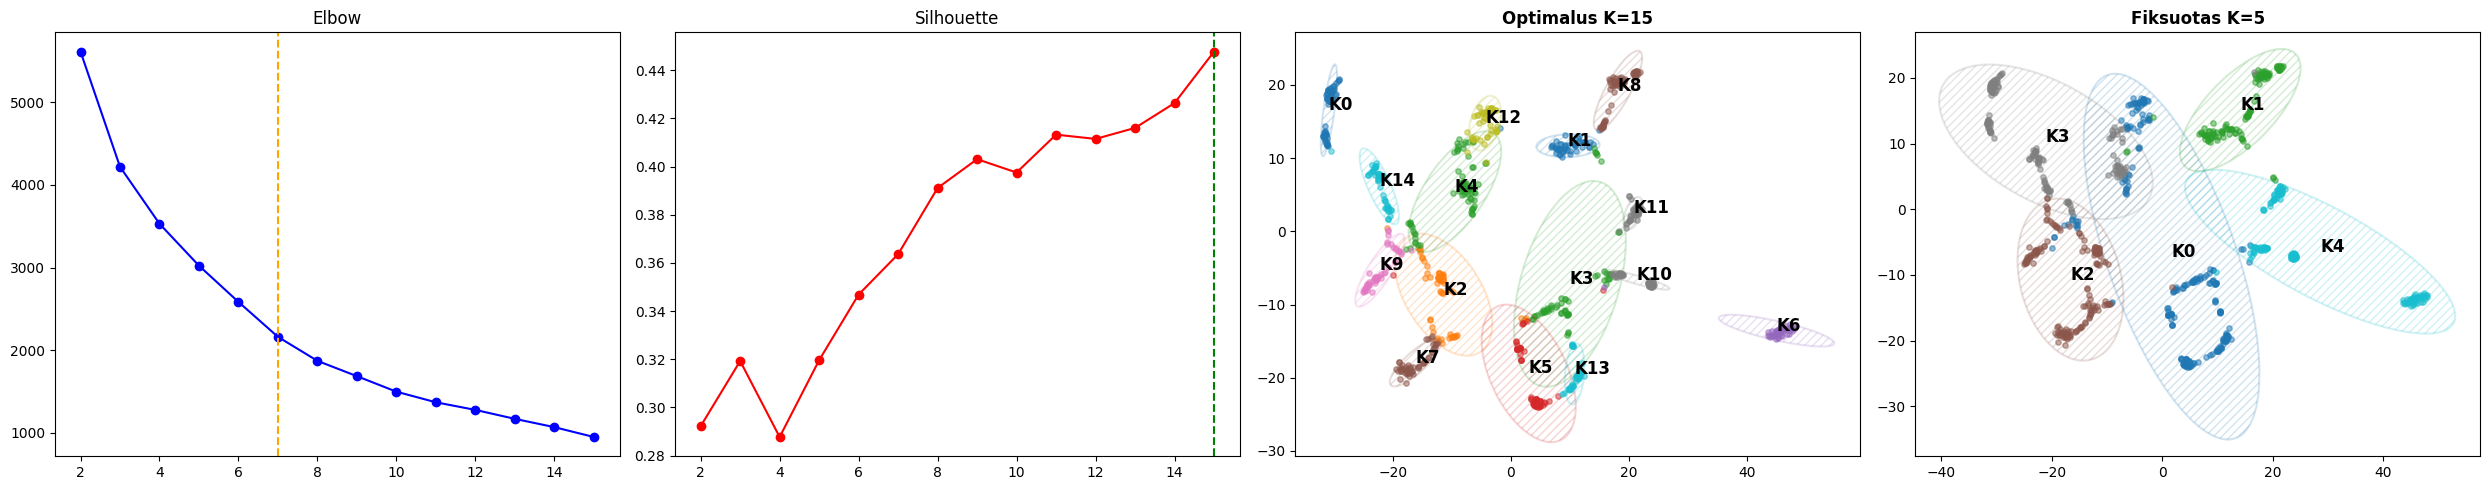

In [ ]:


for d in [2, 25, 50, 100, 150]:
    method = 'barnes_hut' if d <= 3 else 'exact'
    emb = TSNE(n_components=d, metric='precomputed', method=method, init='random', random_state=42).fit_transform(dist_mat)
    final_summary.append(perform_full_analysis(emb, labels_true, f"{d}D"))


In [ ]:

# --- 4. GALUTINIS PALYGINIMAS ---
df_final = pd.DataFrame(final_summary)
print("\n" + "="*100)
print("VISŲ DIMENSIJŲ IR OPTIMALIŲ K PALYGINIMAS")
print("="*100)
print(df_final.to_string(index=False))


VISŲ DIMENSIJŲ IR OPTIMALIŲ K PALYGINIMAS
                                                                                                                                                                                                                                                 0                                                                                                                                                                                                                                              1
{'Dimensija': 'Originali (Opt)', 'K': 15, 'Metodas': 'Silhouette', 'Silhouette': 0.27701261086615947, 'CH': 111.02641866599505, 'DB': 1.3094327215297332, 'ARI': 0.09418530068717032, 'NMI': 0.22992042842173321, 'Jaccard': 0.029884156263451568} {'Dimensija': 'Originali (K=5)', 'K': 5, 'Metodas': 'Fiksuotas', 'Silhouette': 0.23287355530965972, 'CH': 140.12637417533077, 'DB': 1.5211351672372515, 'ARI': 0.12054155366823849, 'NMI': 0.1610593720185553, 'Jaccard': 0.172702513503

# DBSCAN

In [43]:
eps_values = np.linspace(0.0001, np.percentile(embedding, 95), 100)
min_samples_values = range(2, 14)

results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        clusters = DBSCAN(eps=eps, min_samples=min_samples, metric='precomputed').fit_predict(distance_matrix)
        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        mask = clusters != -1

        if n_clusters < 2 or mask.sum() < 2:
            continue

        score = silhouette_score(distance_matrix[np.ix_(mask, mask)], clusters[mask], metric='precomputed')
        jaccard = jaccard_score(labels_encoded, clusters, average='weighted')
        results.append((eps, min_samples, n_clusters, score, jaccard, mask.mean()))


best_eps, best_min_samples, best_n_clusters, best_silhouette, best_jaccard, best_kept = max(
    results,
    key=lambda x: x[3]
)

print(f"Best eps: {best_eps:.5f}")
print(f"Best min_samples: {best_min_samples}")
print(f"Clusters: {best_n_clusters}")
print(f"Silhouette Score: {best_silhouette:.4f}")
print(f"Jaccard Score: {best_jaccard:.4f}")
print(f"Non-noise ratio: {best_kept:.2%}")

Best eps: 0.29636
Best min_samples: 11
Clusters: 2
Silhouette Score: 0.9968
Jaccard Score: 0.0000
Non-noise ratio: 3.73%


In [44]:
eps_values = np.linspace(0.0001, np.percentile(embedding, 95), 100)
min_samples_values = range(2, 14)

results = []
for eps in eps_values:
    for min_samples in min_samples_values:
        clusters = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(embedding)
        n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
        mask = clusters != -1

        if n_clusters < 2 or mask.sum() < 2:
            continue

        score = silhouette_score(embedding[mask], clusters[mask])
        jaccard = jaccard_score(labels_encoded, clusters, average='weighted')
        results.append((eps, min_samples, n_clusters, score, jaccard, mask.mean()))


best_eps, best_min_samples, best_n_clusters, best_silhouette, best_jaccard, best_kept = max(
    results,
    key=lambda x: x[3]
)

print(f"Best eps: {best_eps:.2f}")
print(f"Best min_samples: {best_min_samples}")
print(f"Clusters: {best_n_clusters}")
print(f"Silhouette Score: {best_silhouette:.4f}")
print(f"Jaccard Score: {best_jaccard:.4f}")
print(f"Non-noise ratio: {best_kept:.2%}")

Best eps: 0.00
Best min_samples: 2
Clusters: 2
Silhouette Score: 1.0000
Jaccard Score: 0.0000
Non-noise ratio: 0.67%


In [45]:
dbscan = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric='precomputed')
clusters = dbscan.fit_predict(distance_matrix)

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
print(f"Number of clusters: {n_clusters}")
print(f"Silhouette Score: {silhouette_score(distance_matrix[np.ix_(clusters != -1, clusters != -1)], clusters[clusters != -1], metric='precomputed'):.4f}")
print(f"Jaccard Score: {jaccard_score(labels_encoded, clusters, average='weighted'):.4f}")

Number of clusters: 3
Silhouette Score: 0.7608
Jaccard Score: 0.0000


In [46]:
sorted_results = sorted(results, key=lambda x: x[3], reverse=True)

for eps, min_samples, n_clusters, score, jaccard, kept_ratio in sorted_results[:5]:
    print(
        f"eps={eps:.2f}, min_samples={min_samples}, clusters={n_clusters}, "
        f"silhouette={score:.4f}, jaccard={jaccard:.4f}, non_noise={kept_ratio:.2%}"
    )

eps=0.00, min_samples=2, clusters=2, silhouette=1.0000, jaccard=0.0000, non_noise=0.67%
eps=0.30, min_samples=5, clusters=2, silhouette=0.9972, jaccard=0.0000, non_noise=1.33%
eps=0.59, min_samples=6, clusters=3, silhouette=0.9772, jaccard=0.0000, non_noise=2.40%
eps=0.30, min_samples=4, clusters=13, silhouette=0.9770, jaccard=0.0120, non_noise=7.33%
eps=0.30, min_samples=3, clusters=73, silhouette=0.9568, jaccard=0.0013, non_noise=31.60%


In [54]:
dbscan_final = DBSCAN(eps=best_eps, min_samples=best_min_samples, metric='precomputed')
clusters_final = dbscan_final.fit_predict(distance_matrix)

unique_labels, counts = np.unique(clusters_final, return_counts=True)
cluster_sizes = pd.DataFrame({
    'Cluster': unique_labels,
    'Elements': counts
}).sort_values('Cluster').reset_index(drop=True)

cluster_sizes['Cluster'] = cluster_sizes['Cluster'].apply(
    lambda x: 'Noise (-1)' if x == -1 else f'Cluster {x}'
)

print(cluster_sizes.to_string(index=False))

   Cluster  Elements
Noise (-1)       740
 Cluster 0         4
 Cluster 1         2
 Cluster 2         4


DBSCAN algoritmo nenaudosime, nes 740 stebėjimų algoritmo laikomi triukšmu.